## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%matplotlib inline

In [3]:
customers = pd.read_csv("ecommerce_customers.csv")

## Let's check the head of customers, and check out its info() and describe() methods.

In [4]:
customers.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,user0@yahoo.com,"London, UK",avatar6.png,33.99,10.72,38.59,1.78,719.49
1,user1@outlook.com,"Dubai, UAE",avatar46.png,33.12,13.02,33.68,1.92,661.17
2,user2@gmail.com,"Toronto, Canada",avatar47.png,32.97,7.17,29.10,4.06,648.00
3,user3@outlook.com,"London, UK",avatar35.png,30.29,9.52,33.19,4.93,632.49
4,user4@yahoo.com,"London, UK",avatar50.png,32.27,8.15,33.82,4.04,693.14


In [5]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 1200 non-null   object 
 1   Address               1200 non-null   object 
 2   Avatar                1200 non-null   object 
 3   Avg. Session Length   1200 non-null   float64
 4   Time on App           1200 non-null   float64
 5   Time on Website       1200 non-null   float64
 6   Length of Membership  1200 non-null   float64
 7   Yearly Amount Spent   1200 non-null   float64
dtypes: float64(5), object(3)
memory usage: 75.1+ KB


In [6]:
customers.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,31.800758,11.057333,35.971250,3.445842,711.367442
std,4.063453,2.003452,3.851617,1.447818,103.994649
min,19.600000,4.760000,23.970000,1.000000,405.550000
25%,29.077500,9.680000,33.227500,2.180000,638.042500
50%,31.955000,11.040000,36.055000,3.395000,709.175000
75%,34.540000,12.400000,38.720000,4.750000,782.570000
max,43.800000,17.230000,48.360000,5.990000,1023.430000


## Exploratory Data Analysis
### Let's explore the data!

### For the rest of the exercise we'll only be using the numerical data of the csv file.



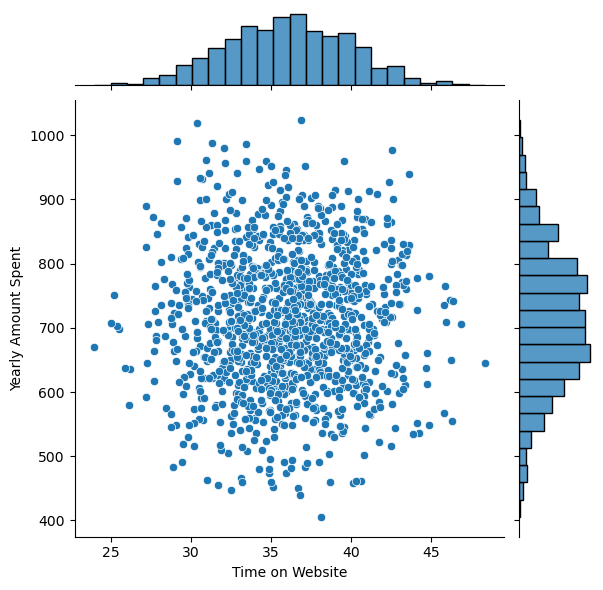

In [7]:
sns.jointplot(data=customers,x='Time on Website',y='Yearly Amount Spent')

### Let's do the same but with the Time on App column instead

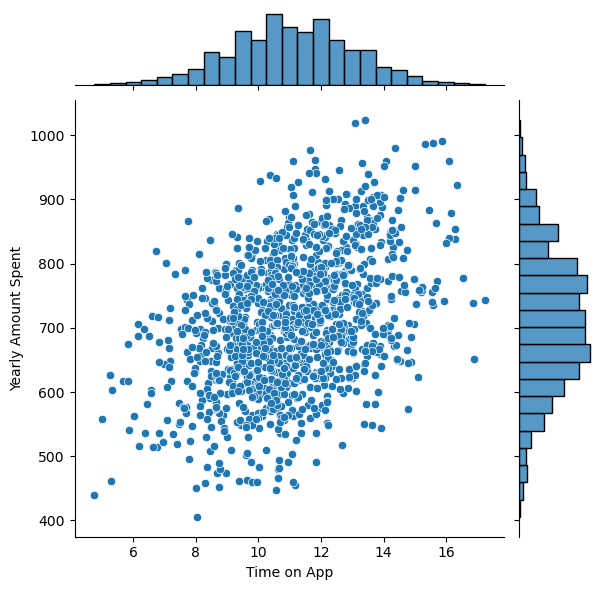

In [8]:
sns.jointplot(data=customers,x='Time on App',y='Yearly Amount Spent')

## Let's use jointplot to create a 2D hex bin plot comparing Time on App and Length of Membership.

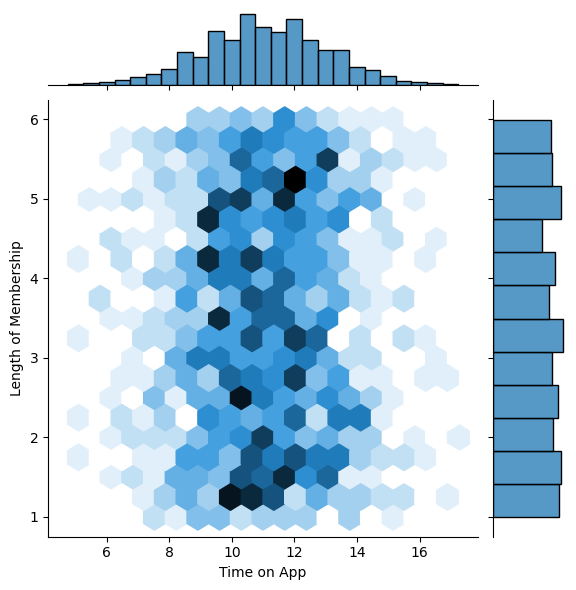

In [9]:
sns.jointplot(data=customers,x='Time on App', y='Length of Membership', kind='hex')

### Let's explore these types of relationships across the entire data set. Use pairplot to recreate the plot below.

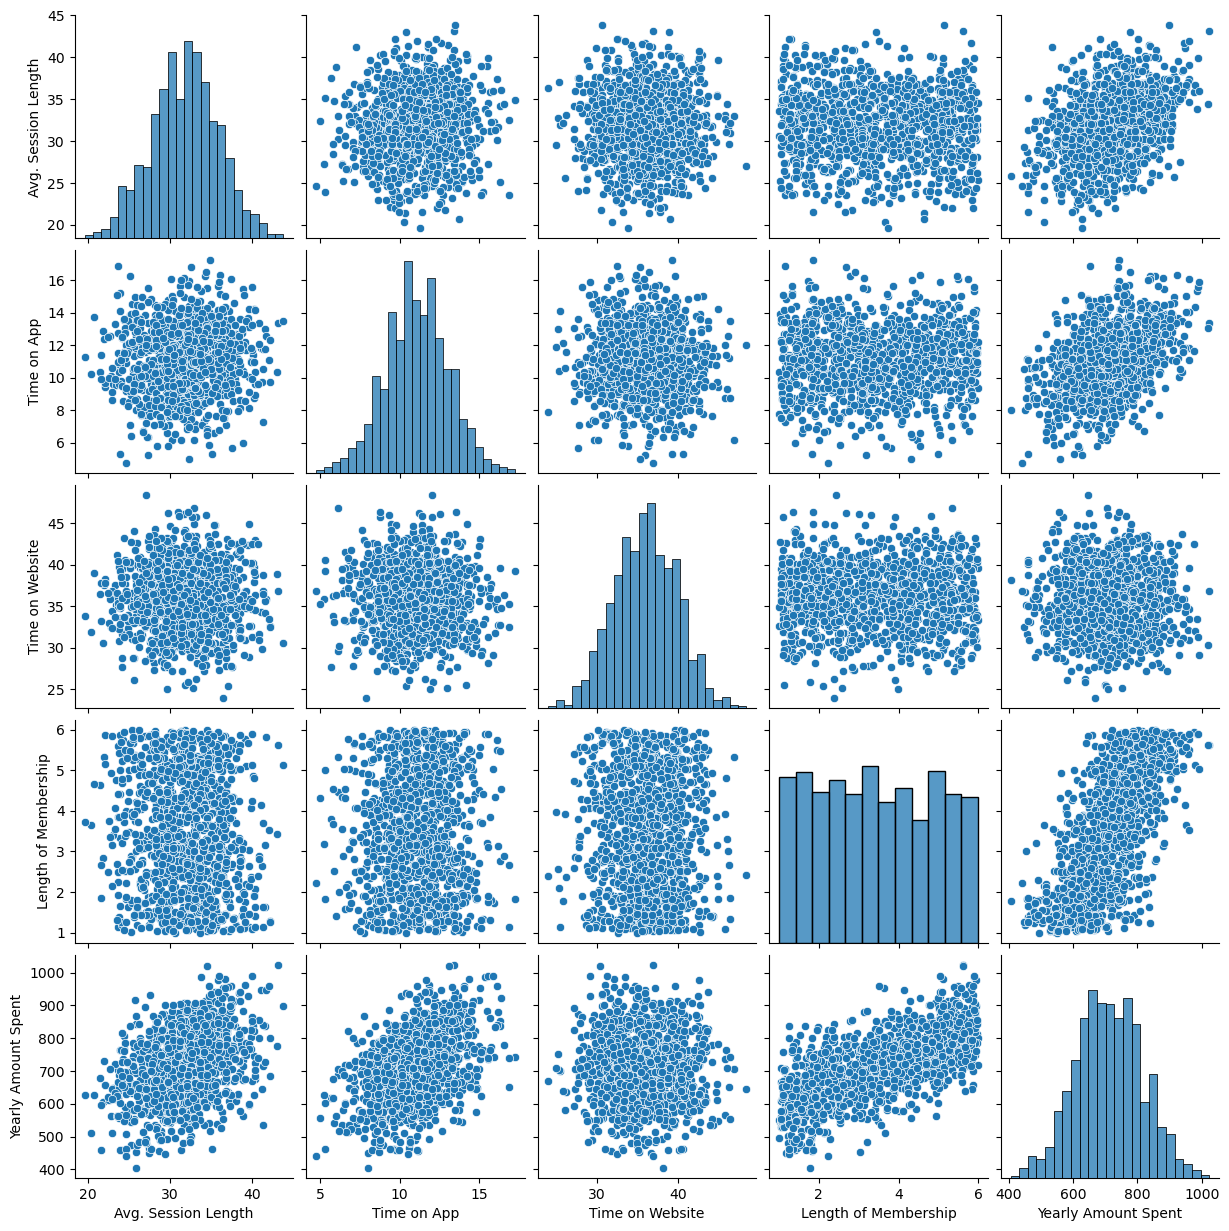

In [10]:
sns.pairplot(customers)

### Let's create a linear model plot (using seaborn's lmplot) of Yearly Amount Spent vs. Length of Membership.

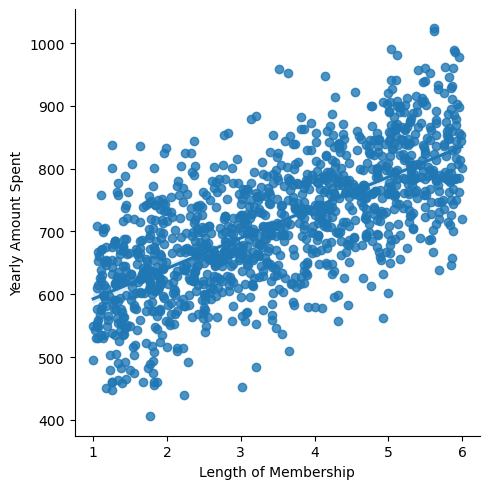

In [11]:

sns.lmplot(data=customers,x='Length of Membership', y='Yearly Amount Spent')

# Training and Testing Data

Now that we've explored the data a bit, let's go ahead and split the data into training and testing sets. Set a variable X equal to the numerical features of the customers and a variable y equal to the "Yearly Amount Spent" column.

In [12]:
customers.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

In [13]:
y = customers['Yearly Amount Spent']

In [14]:
X = customers[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# Training the Model
### Now its time to train our model on our training data!

### Import LinearRegression from sklearn.linear_model

In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
lm = LinearRegression()

In [19]:
lm.fit(X_train,y_train)

LinearRegression()

In [20]:
lm.coef_

array([10.41630595, 19.07973068, -0.43699761, 50.94195995])

## Predicting Test Data
### Now that we have fit our model, let's evaluate its performance by predicting off the test values!

### Use lm.predict() to predict off the X_test set of the data.

In [21]:
predictions = lm.predict(X_test)

## Let's create a scatterplot of the real test values versus the predicted values.

Text(0, 0.5, 'Predicted Values')

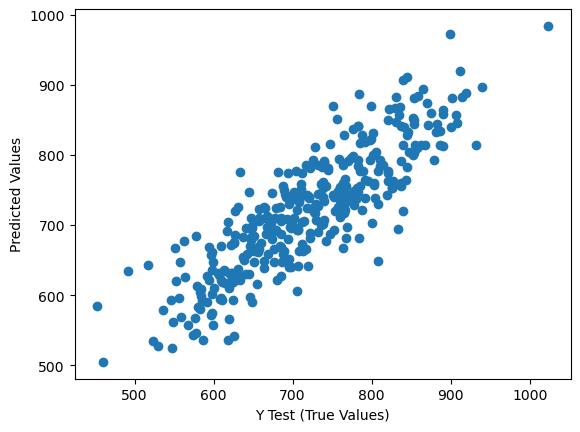

In [22]:
plt.scatter(y_test, predictions)
plt.xlabel('Y Test (True Values)')
plt.ylabel('Predicted Values')

## Evaluating the Model
### Let's evaluate our model performance by calculating the residual sum of squares and the explained variance score (R^2).

### Calculate the Mean Absolute Error, Mean Squared Error, and the Root Mean Squared Error. Refer to the lecture or to Wikipedia for the formulas

In [23]:
from sklearn import metrics

In [24]:
print('MAE', metrics.mean_absolute_error(y_test,predictions))
print('MSE', metrics.mean_squared_error(y_test,predictions))
print('RMSE',np.sqrt(metrics.mean_squared_error(y_test,predictions)))

MAE 38.44997949649686
MSE 2350.7156867643976
RMSE 48.48417975757038


In [25]:

# (R^2)
metrics.explained_variance_score(y_test, predictions)

0.745796083680804

# Residuals

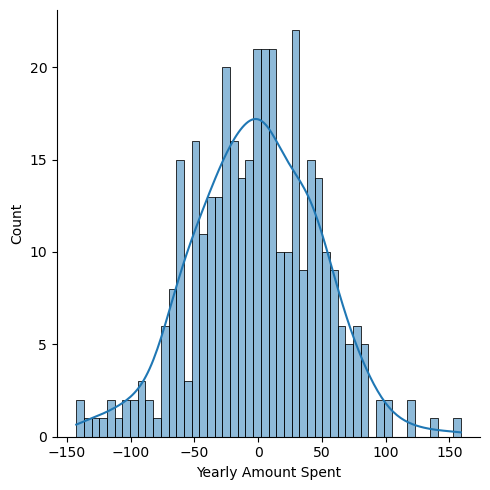

In [26]:
sns.displot(y_test - predictions, bins=50, kde=True)

In [27]:
cdf = pd.DataFrame(lm.coef_,X.columns,columns=['Coeff'])
cdf

,Coeff
Avg. Session Length,10.416306
Time on App,19.079731
Time on Website,-0.436998
Length of Membership,50.941960


✅ 1. Avg. Session Length → +10.42
If session length increases by 1 unit
→ yearly spending increases by ~$10.4

👉 Moderate positive effect

✅ 2. Time on App → +19.08
1 unit increase in app usage
→ spending increases by ~$19.1

👉 Strong driver of revenue

⚠️ 3. Time on Website → −0.44
1 unit increase in website usage
→ spending decreases slightly (~$0.44)

👉 Important insight:

This is negative + very small
Practically:
Website is not helping conversions
Might even indicate friction / poor UX
🚀 4. Length of Membership → +50.94
1 unit increase
→ spending increases by ~$51


🎯 Business Decision (Sharp Answer)

👉 The company should focus more on the mobile app, because:

It has a strong positive impact
Website has no meaningful contribution (even slightly negative)


🤔 But cann’t ignore this nuance 


“The negative coefficient for Time on Website suggests potential issues with the website experience. Instead of ignoring it, the company should investigate whether improving the website could unlock additional revenue.”